# Example: Schleiz

This example was published by Martin et al. (2020) on the testsite Schleiz.
The data and all scripts are accessible on [Zenodo](https://doi.org/10.5281/zenodo.4419735).
A shallow pyrite-rich blackshale was measured with ABEM Terrameter LS2.

In [29]:
from tdip import TDIP

We read the data as DIP file (from Aarhus Workbench processing).
Other possible formats are txt exports from ABEM or Syscal software.

In [30]:
from tdip.importtdipdata import importDIP
import numpy as np

In [31]:
tdip = TDIP("Profile1-DD-4s-new-proc_corr.dip")
print(tdip)

TDIP data: Data: Sensors: 42 data: 829, nonzero entries: ['a', 'b', 'k', 'm', 'n', 'rhoa', 'valid']
MA shape = (25, 829) nt=25 (t=0.001-3.192s)
ipDT = array((25,))
delay = 0.0009500000000000001
ipGateT = array((26,))


The data set constists of 829 quadrupoles using 42 electrodes.
Apparent chargeability is present in 25 gates from 1ms to 3s.
The apparent resistivity was shown in Fig. 4 (upper right) of the paper.

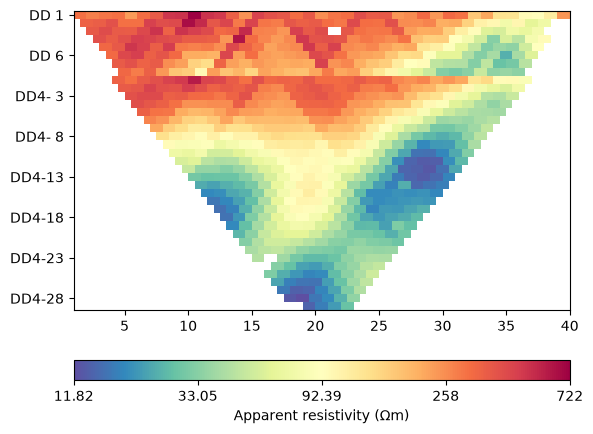

In [32]:
tdip.showData();

First, we invert for the resistivity using a rather fine and high-quality mesh with a maximum depth of 12m.

26/06/26 - 17:57:50 - pyGIMLi - INFO - Found 2 regions.
26/06/26 - 17:57:50 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
26/06/26 - 17:57:50 - pyGIMLi - INFO - Found 2 regions.
26/06/26 - 17:57:50 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
26/06/26 - 17:57:50 - pyGIMLi - INFO - Creating forward mesh from region infos.
26/06/26 - 17:57:50 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
26/06/26 - 17:57:50 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 3868 Cells: 7348 Boundaries: 5704
26/06/26 - 17:57:50 - pyGIMLi - INFO - Use median(data values)=105.6269
26/06/26 - 17:57:50 - pyGIMLi - INFO - Created startmodel from forward operator:1093, min/max=105.626900/105.626900
26/06/26 - 17:57:50 - pyGIMLi - INFO - Starting inversion.
26/06/26 - 17:57:50 - pyGIMLi - INFO - fop: <pygimli.physics.ert.ertModelling.ERTModelling object at 0x000002029E3AF380>
26/06/26 - 17:57:50 - pyGIMLi - INFO - Data transf

--------------------------------------------------------------------------------
--------------------------------------------------------------------------------
inv.iter 1 ... 

26/06/26 - 17:57:52 - pyGIMLi - INFO - chi² =  102.51 (dPhi = 91.33%) lam: 20.0


--------------------------------------------------------------------------------
inv.iter 2 ... 

26/06/26 - 17:57:53 - pyGIMLi - INFO - chi² =   34.23 (dPhi = 65.03%) lam: 20.0
26/06/26 - 17:57:54 - pyGIMLi - INFO - chi² =    2.19 (dPhi = 84.47%) lam: 20.0


...

26/06/26 - 17:57:57 - pyGIMLi - INFO - chi² =    1.31 (dPhi = 5.10%) lam: 20.0
26/06/26 - 17:57:59 - pyGIMLi - INFO - chi² =    1.13 (dPhi = 2.74%) lam: 20.0


--------------------------------------------------------------------------------
inv.iter 6 ... --------------------------------------------------------------------------------
inv.iter 7 ... 

26/06/26 - 17:58:00 - pyGIMLi - INFO - chi² =    1.12 (dPhi = 0.23%) lam: 20.0


################################################################################
#                Abort criterion reached: dPhi = 0.23 (< 2.0%)                 #
################################################################################


(<Axes: xlabel='$x$ in m', ylabel='Depth in m'>,
 <matplotlib.colorbar.Colorbar at 0x2029f71c2d0>)

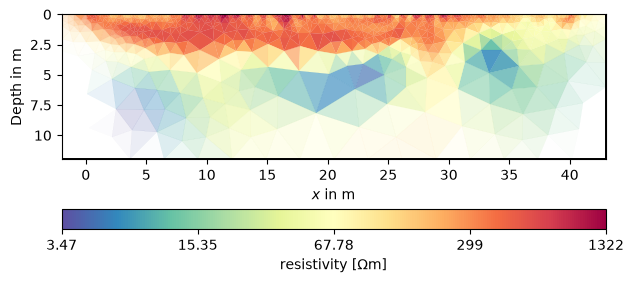

In [33]:
tdip.invertRhoa(paraDepth=12, quality=34.4, paraDX=0.25, verbose=True, show=True)

The result is very similar to Fig. 10, third row left.
We fit the decays using a Debye model (only using gates above 100ms) and obtain apparent relaxation times of about 1-2s.

(<Axes: >, <matplotlib.colorbar.Colorbar at 0x202b9bede50>)

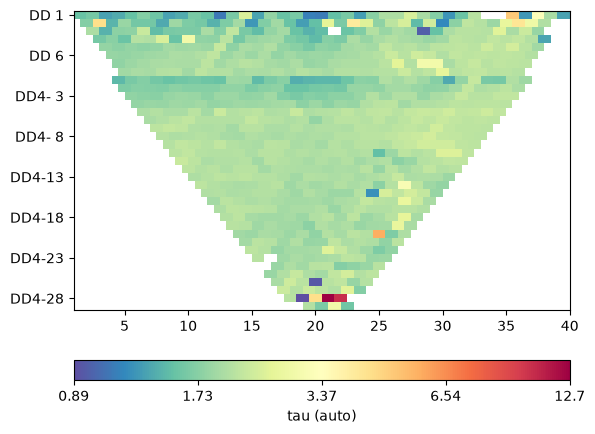

In [41]:
tdip.fitDataDecays(tmin=0.1)
# tdip.generateDataPDF()  # produces a multi-page pdf
tdip.showData("tau")

We show all decays for the same AB combination as in Fig. 8.
The function `generateDecayPDF()` generates a multi-page pdf of all AB.

nr= [199 200 201 202 203 204 205 206]
fit = [0.10 0.14 0.17 0.14 0.14 0.12 0.15 0.11]


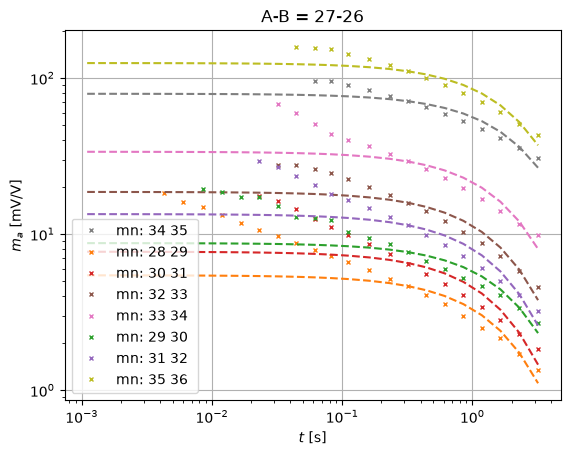

In [44]:
tdip.showDecay(ab=[26, 27], showFit=True, xscale="log")#, yscale="linear")
if 0:  # creates a multi-page pdf file with all AB on separate pages
    tdip.generateDecayPDF(showFit=True)

We plot a single apparent chargeability of gate 16 like in Fig. 6 (third row).

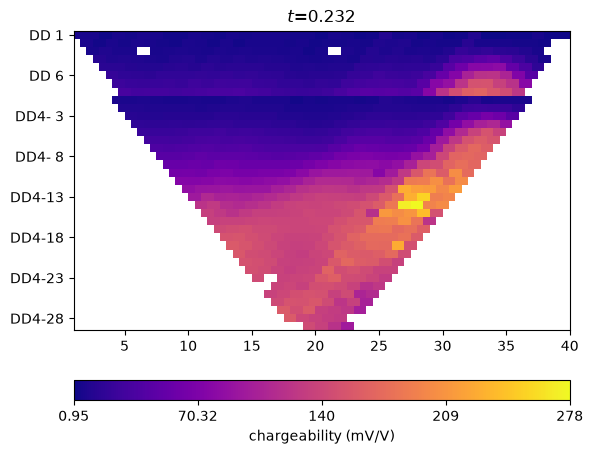

In [36]:
tdip.showMa(16, logScale=False);

This gate can be inverted individually.

In [45]:
tdip.invertMa(16, error=0.01)

26/06/26 - 23:02:42 - pyGIMLi - INFO - Found 2 regions.
26/06/26 - 23:02:42 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
26/06/26 - 23:02:42 - pyGIMLi - INFO - Starting inversion.
26/06/26 - 23:02:42 - pyGIMLi - INFO - fop: <tdip.modelling.DCIPMModelling object at 0x00000202B9BD09F0>
26/06/26 - 23:02:42 - pyGIMLi - INFO - Data transformation: Identity transform
26/06/26 - 23:02:42 - pyGIMLi - INFO - Model transformation: Logarithmic LU transform, lower bound 0.0001, upper bound 0.999
26/06/26 - 23:02:42 - pyGIMLi - INFO - min/max (data): 0.0015/117
26/06/26 - 23:02:42 - pyGIMLi - INFO - min/max (error): 3.14%/1.4e+06%
26/06/26 - 23:02:42 - pyGIMLi - INFO - min/max (start model): 0.05/0.05
26/06/26 - 23:02:43 - pyGIMLi - INFO - inv.iter 0 ... chi² =   57.31


--------------------------------------------------------------------------------
--------------------------------------------------------------------------------
inv.iter 1 ... 

26/06/26 - 23:02:44 - pyGIMLi - INFO - chi² =   20.79 (dPhi = 62.63%) lam: 100.0


--------------------------------------------------------------------------------
inv.iter 2 ... 

26/06/26 - 23:02:46 - pyGIMLi - INFO - chi² =    4.04 (dPhi = 71.53%) lam: 100.0


--------------------------------------------------------------------------------
inv.iter 3 ... 

26/06/26 - 23:02:47 - pyGIMLi - INFO - chi² =    2.41 (dPhi = 11.97%) lam: 100.0


--------------------------------------------------------------------------------
inv.iter 4 ... 

26/06/26 - 23:02:48 - pyGIMLi - INFO - chi² =    2.52 (dPhi = 0.57%) lam: 100.0


################################################################################
#                Abort criterion reached: dPhi = 0.57 (< 2.0%)                 #
################################################################################
chi^2=2.5 RMS=4051.3mV/V


The result looks similar to the one in Fig. 10, third row, right.

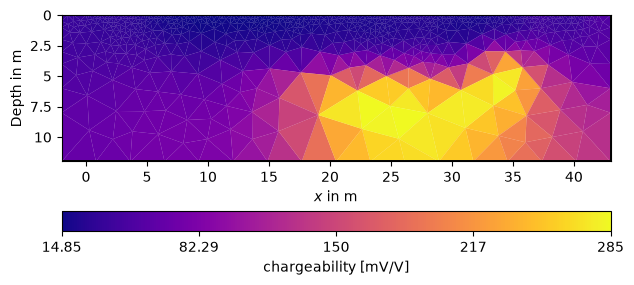

In [46]:
tdip.showChargeability();

We can invert all gates using a Debye approach.

In [47]:
tdip.filter(tmin=0.1)
tdip.invertDebye(verbose=True)

26/06/26 - 23:04:13 - pyGIMLi - INFO - Starting inversion.
26/06/26 - 23:04:13 - pyGIMLi - INFO - fop: <pygimli.frameworks.modelling.LinearModelling object at 0x000002029DA193F0>
26/06/26 - 23:04:13 - pyGIMLi - INFO - Data transformation: Identity transform
26/06/26 - 23:04:13 - pyGIMLi - INFO - Model transformation: Logarithmic transform
26/06/26 - 23:04:13 - pyGIMLi - INFO - min/max (data): 1.8e-05/0.35
26/06/26 - 23:04:13 - pyGIMLi - INFO - min/max (error): 3.28%/1.0e+07%
26/06/26 - 23:04:13 - pyGIMLi - INFO - min/max (start model): 0.03/0.03
26/06/26 - 23:04:13 - pyGIMLi - INFO - inv.iter 0 ... chi² = 6544.28


filtering: nt=25, nd=829
filtered: nt=11, nd=829
--------------------------------------------------------------------------------
--------------------------------------------------------------------------------
inv.iter 1 ... 

26/06/26 - 23:04:17 - pyGIMLi - INFO - chi² =  820.23 (dPhi = 87.46%) lam: 20.0


--------------------------------------------------------------------------------
inv.iter 2 ... 

26/06/26 - 23:04:21 - pyGIMLi - INFO - chi² =   94.98 (dPhi = 88.34%) lam: 20.0


...

--------------------------------------------------------------------------------
inv.iter 5 ... 

26/06/26 - 23:04:29 - pyGIMLi - INFO - chi² =    2.40 (dPhi = 6.63%) lam: 20.0


--------------------------------------------------------------------------------
inv.iter 6 ... 

26/06/26 - 23:04:32 - pyGIMLi - INFO - chi² =    2.41 (dPhi = 0.08%) lam: 20.0


################################################################################
#                Abort criterion reached: dPhi = 0.08 (< 2.0%)                 #
################################################################################


The result is contained in the field `modelDebye`, but also inside the mesh (`tdip.pd`) as total chargeability and log-mean tau.

In [53]:
print(tdip.pd, tdip.modelDebye.shape)

Mesh: Nodes: 627 Cells: 1093 Boundaries: 159
Mesh contains data: TC, logMeanTau (11, 1093)


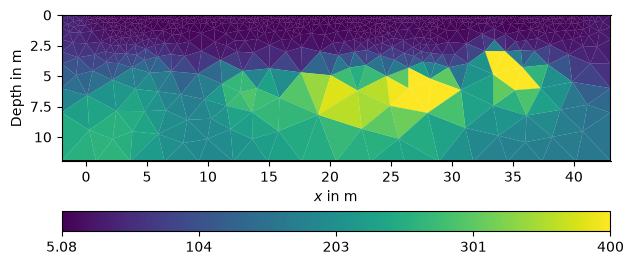

In [57]:
tdip.pd.show("TC", factor=1000, cMax=400);